Module __main__ aef6b4f load on device 'cuda:0' took 184.17 ms  (compiled)


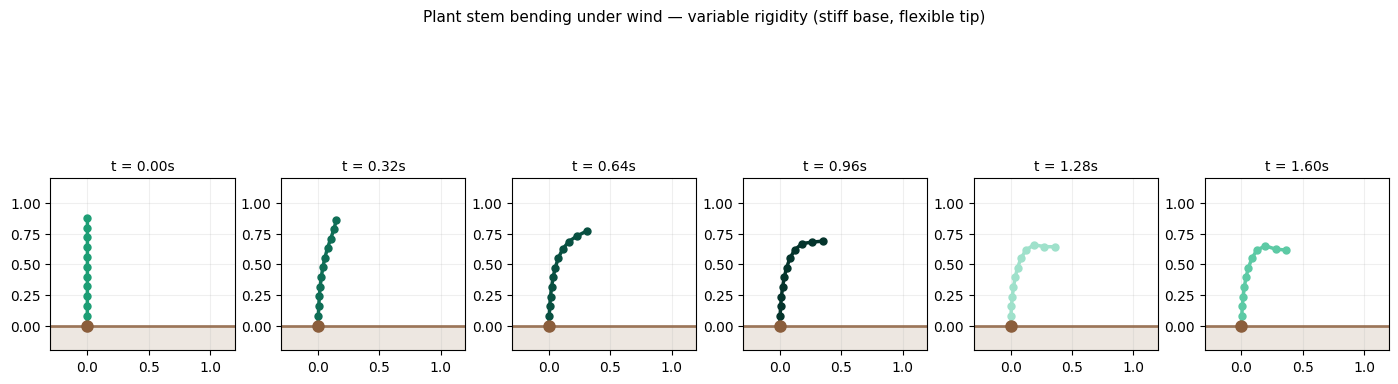

Saved stem_bending.png


In [10]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

@wp.kernel
def apply_forces(
    positions: wp.array(dtype=wp.vec3),
    velocities: wp.array(dtype=wp.vec3),
    dt: float
):
    i = wp.tid()
    if i == 0:
        return

    wind    = wp.vec3(4.0,  0.0, 0.0)
    gravity = wp.vec3(0.0, -0.5, 0.0)   # very mild gravity
    damping = float(0.94)
    velocities[i] = (velocities[i] + (gravity + wind) * dt) * damping
    positions[i]  =  positions[i]  + velocities[i] * dt


def enforce_constraints_cpu(pos_np, vel_np, rest_length, n):
    """
    Variable stiffness: bottom nodes nearly rigid, tip nodes flexible.
    Stiffness = inversely proportional to distance from ground.
    Node 0 (root) = fully fixed.
    Node 1 (just above root) = 95% pulled back toward vertical.
    Node 11 (tip) = only 20% pulled back → bends freely.
    """
    # Always pin root first
    pos_np[0] = [0.0, 0.0, 0.0]
    vel_np[0] = [0.0, 0.0, 0.0]

    # Walk root → tip, enforcing distance constraint
    for i in range(1, n):
        parent = pos_np[i - 1]
        child  = pos_np[i]
        diff   = child - parent
        dist   = np.linalg.norm(diff)
        if dist > 1e-6:
            unit      = diff / dist
            pos_np[i] = parent + unit * rest_length  # maintain stem length

    # Second pass: apply rigidity pull toward vertical
    # Lower nodes pulled strongly back toward vertical axis
    # Upper nodes allowed to deviate freely → natural plant curve
    for i in range(1, n):
        t = i / (n - 1)                  # 0.0 at root, 1.0 at tip

        # Stiffness: 0.95 at base → 0.05 at tip (inversely proportional to height)
        stiffness = 0.95 * (1.0 - t) + 0.05 * t

        # Ideal position = directly above parent on Y axis (perfectly vertical)
        parent     = pos_np[i - 1]
        ideal_x    = parent[0]           # same X as parent = perfectly upright
        actual_x   = pos_np[i][0]

        # Pull X toward ideal (vertical) proportionally to stiffness
        pos_np[i][0] = actual_x + (ideal_x - actual_x) * stiffness

    # Clamp: no node goes below ground (y=0)
    for i in range(n):
        if pos_np[i][1] < 0.0:
            pos_np[i][1] = 0.0
            vel_np[i][1] = 0.0

    return pos_np, vel_np


n           = 12
rest_length = 0.08

pos_np = np.array(
    [[0.0, i * rest_length, 0.0] for i in range(n)],
    dtype=np.float32
)
vel_np = np.zeros((n, 3), dtype=np.float32)

frames = []
for frame in range(120):
    pos_gpu = wp.array(pos_np, dtype=wp.vec3, device="cuda")
    vel_gpu = wp.array(vel_np, dtype=wp.vec3, device="cuda")

    wp.launch(apply_forces, dim=n, inputs=[pos_gpu, vel_gpu, 0.016])

    pos_np = pos_gpu.numpy().copy()
    vel_np = vel_gpu.numpy().copy()

    pos_np, vel_np = enforce_constraints_cpu(pos_np, vel_np, rest_length, n)

    if frame % 20 == 0:
        frames.append(pos_np.copy())

# Plot
fig, axes = plt.subplots(1, len(frames), figsize=(14, 5))
colors = ['#1D9E75', '#0F6E56', '#085041', '#04342C', '#9FE1CB', '#5DCAA5']

for idx, (ax, frame_pos) in enumerate(zip(axes, frames)):
    # Fill ground
    ax.axhspan(-0.5, 0.0, color='#8B5E3C', alpha=0.15)  # brown ground fill
    ax.axhline(y=0, color='#8B5E3C', linewidth=2, alpha=0.8)  # solid ground line

    ax.plot(frame_pos[:, 0], frame_pos[:, 1],
            'o-', color=colors[idx % len(colors)],
            linewidth=2.5, markersize=5)

    # Highlight root node
    ax.plot(frame_pos[0, 0], frame_pos[0, 1],
            'o', color='#8B5E3C', markersize=8, zorder=5)

    ax.set_xlim(-0.3, 1.2)
    ax.set_ylim(-0.2, 1.2)
    ax.set_title(f't = {idx * 20 * 0.016:.2f}s', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle('Plant stem bending under wind — variable rigidity (stiff base, flexible tip)',
             fontsize=11)
plt.tight_layout()
plt.savefig('stem_bending.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved stem_bending.png")